
# 03 - Baseline Training (MSE + Fixed Beta)

This notebook trains a baseline Beta-VAE using:
- reconstruction loss: MSE
- KL weight: fixed `beta`

The notebook saves the trained checkpoint for later comparison and analysis.


In [1]:
import os
import warnings

# Silence Python-level warnings in notebook output.
warnings.filterwarnings('ignore')

# Reduce noisy runtime warnings from OpenMP/MKL in some environments.
os.environ['KMP_WARNINGS'] = '0'
os.environ['MKL_VERBOSE'] = '0'

import warnings
warnings.filterwarnings("ignore")

In [2]:

from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'processed_sneakers_64x64').exists() or (cwd / 'BayesML_Final_Project.ipynb').exists():
        return cwd
    if (cwd / '..' / 'processed_sneakers_64x64').resolve().exists() or (cwd / '..' / 'BayesML_Final_Project.ipynb').resolve().exists():
        return (cwd / '..').resolve()
    return cwd


PROJECT_ROOT = resolve_project_root()
PROJECT_ROOT


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


PosixPath('/Users/hjjh/Desktop/ML Project/Sneaker-Design-VAE')

## Training Configuration

In [3]:

PROCESSED_DATA_DIR = PROJECT_ROOT / 'processed_sneakers_64x64'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
CHECKPOINT_DIR = ARTIFACTS_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 128
NUM_WORKERS = 4
LATENT_DIM = 16
LEARNING_RATE = 1e-3
EPOCHS = 20
BETA = 4.0
SEED = 42

if not PROCESSED_DATA_DIR.exists():
    raise FileNotFoundError(
        f'Processed dataset not found at {PROCESSED_DATA_DIR}. '
        'Run 01_data_preprocessing.ipynb first.'
    )

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Project root: {PROJECT_ROOT}')
print(f'Processed data: {PROCESSED_DATA_DIR}')
print(f'Checkpoints: {CHECKPOINT_DIR}')


Project root: /Users/hjjh/Desktop/ML Project/Sneaker-Design-VAE
Processed data: /Users/hjjh/Desktop/ML Project/Sneaker-Design-VAE/processed_sneakers_64x64
Checkpoints: /Users/hjjh/Desktop/ML Project/Sneaker-Design-VAE/artifacts/checkpoints


## DataLoader

In [4]:

transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root=PROCESSED_DATA_DIR, transform=transform)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

print(f'Dataset size: {len(dataset)}')
print(f'Batches per epoch: {len(dataloader)}')


Dataset size: 12856
Batches per epoch: 101


## Model Definition

In [5]:

class BetaVAE(nn.Module):
    def __init__(self, latent_dim: int = 16):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )

        self.fc_mu = nn.Linear(4096, latent_dim)
        self.fc_log_var = nn.Linear(4096, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 4096)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def reparameterize(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x: torch.Tensor):
        encoded = self.encoder(x)
        flat = torch.flatten(encoded, start_dim=1)
        mu = self.fc_mu(flat)
        log_var = self.fc_log_var(flat)
        z = self.reparameterize(mu, log_var)

        decoded = self.fc_decode(z)
        decoded = decoded.view(-1, 256, 4, 4)
        reconstruction = self.decoder(decoded)
        return reconstruction, mu, log_var


## Loss Function and Training Loop

In [6]:

def beta_vae_loss_mse(
    reconstruction: torch.Tensor,
    target: torch.Tensor,
    mu: torch.Tensor,
    log_var: torch.Tensor,
    beta: float,
):
    # Baseline Beta-VAE loss with MSE reconstruction term.
    recon_loss = F.mse_loss(reconstruction, target, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss


def train_baseline(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: optim.Optimizer,
    device: torch.device,
    epochs: int,
    beta: float,
):
    history = {
        'total_loss': [],
        'recon_loss': [],
        'kl_loss': [],
    }

    for epoch in range(epochs):
        model.train()
        running_total = 0.0
        running_recon = 0.0
        running_kl = 0.0

        for batch, _ in dataloader:
            batch = batch.to(device)
            optimizer.zero_grad()

            reconstruction, mu, log_var = model(batch)
            total_loss, recon_loss, kl_loss = beta_vae_loss_mse(reconstruction, batch, mu, log_var, beta)

            total_loss.backward()
            optimizer.step()

            running_total += total_loss.item()
            running_recon += recon_loss.item()
            running_kl += kl_loss.item()

        dataset_size = len(dataloader.dataset)
        avg_total = running_total / dataset_size
        avg_recon = running_recon / dataset_size
        avg_kl = running_kl / dataset_size

        history['total_loss'].append(avg_total)
        history['recon_loss'].append(avg_recon)
        history['kl_loss'].append(avg_kl)

        print(
            f'Epoch {epoch + 1:02d}/{epochs} | '
            f'Total: {avg_total:.4f} | Recon: {avg_recon:.4f} | KL: {avg_kl:.4f}'
        )

    return history


## Train Baseline Model

In [7]:

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

model = BetaVAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f'Using device: {device}')
history = train_baseline(model, dataloader, optimizer, device, EPOCHS, BETA)


Using device: mps
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) A

## Plot Training Curves

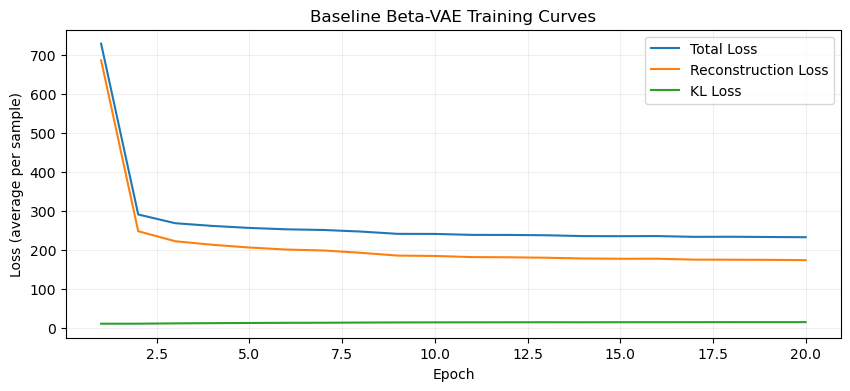

In [8]:

epochs_range = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, history['total_loss'], label='Total Loss')
plt.plot(epochs_range, history['recon_loss'], label='Reconstruction Loss')
plt.plot(epochs_range, history['kl_loss'], label='KL Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (average per sample)')
plt.title('Baseline Beta-VAE Training Curves')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


## Save Baseline Checkpoint

In [9]:

baseline_checkpoint_path = CHECKPOINT_DIR / 'beta_vae_baseline.pt'

torch.save(
    {
        'latent_dim': LATENT_DIM,
        'model_state_dict': model.state_dict(),
        'history': history,
        'beta': BETA,
        'epochs': EPOCHS,
        'loss_type': 'mse',
        'classes': dataset.classes,
    },
    baseline_checkpoint_path,
)

print(f'Baseline checkpoint saved to: {baseline_checkpoint_path}')


Baseline checkpoint saved to: /Users/hjjh/Desktop/ML Project/Sneaker-Design-VAE/artifacts/checkpoints/beta_vae_baseline.pt
